<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/Goniaa_StyleLex_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 2: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Perceptron, SGDRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tensorflow.keras.datasets import fashion_mnist


In [ ]:
# STEP 3: Load Goniaa StyleLex Dataset (Fashion-MNIST)
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data:", X_train.shape)
print("Test Data:", X_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data: (60000, 28, 28)
Test Data: (10000, 28, 28)


In [ ]:
# STEP 4: Preprocessing (Normalization + Reshape)

# 0-255 → 0-1
X_train = X_train / 255.0
X_test  = X_test / 255.0

# 28x28 → 784 vector
X_train = X_train.reshape(len(X_train), -1)
X_test  = X_test.reshape(len(X_test), -1)

print("New shape:", X_train.shape)


New shape: (60000, 784)


In [ ]:
# STEP 5: Train Perceptron Model

perceptron = Perceptron(max_iter=1000)
perceptron.fit(X_train, y_train)

y_pred_p = perceptron.predict(X_test)

print("Perceptron Done!")


Perceptron Done!


In [ ]:
# STEP 6: Train Adaline Model

adaline = SGDRegressor(loss="squared_error", max_iter=1000)
adaline.fit(X_train, y_train)

# Predict and round to nearest class (0–9)
y_pred_a = np.rint(adaline.predict(X_test)).astype(int)
y_pred_a = np.clip(y_pred_a, 0, 9)

print("Adaline Done!")


Adaline Done!


In [ ]:
# STEP 7: Train Madaline Model (MLP)

madaline = MLPClassifier(hidden_layer_sizes=(128,), activation='relu', max_iter=20)
madaline.fit(X_train, y_train)

y_pred_m = madaline.predict(X_test)

print("Madaline Done!")


Madaline Done!


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# STEP 8: Evaluation Function

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro', zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average='macro', zero_division=0))
    print("F1 Score :", f1_score(y_true, y_pred, average='macro', zero_division=0))

evaluate_model("Perceptron", y_test, y_pred_p)
evaluate_model("Adaline", y_test, y_pred_a)
evaluate_model("Madaline", y_test, y_pred_m)



Perceptron Results
Accuracy : 0.7834
Precision: 0.815143602582242
Recall   : 0.7834
F1 Score : 0.7801634708553998

Adaline Results
Accuracy : 0.381
Precision: 0.40641094997040667
Recall   : 0.381
F1 Score : 0.3763055518156401

Madaline Results
Accuracy : 0.8853
Precision: 0.8873967298222913
Recall   : 0.8853
F1 Score : 0.8852923445146169


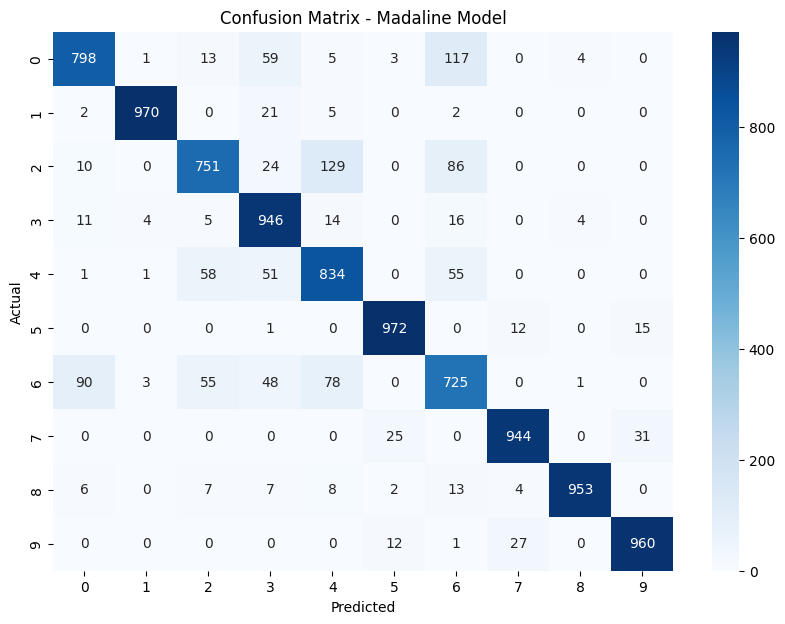

In [ ]:
# STEP 9: Confusion Matrix for Madaline

cm = confusion_matrix(y_test, y_pred_m)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Madaline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


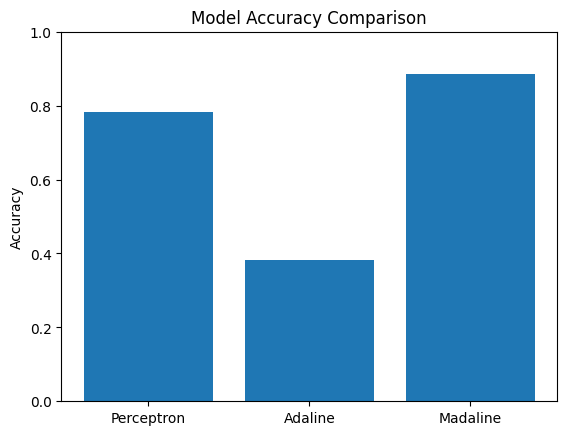

In [ ]:
# STEP 10: Accuracy Comparison Chart

acc_values = [
    accuracy_score(y_test, y_pred_p),
    accuracy_score(y_test, y_pred_a),
    accuracy_score(y_test, y_pred_m)
]

plt.bar(["Perceptron", "Adaline", "Madaline"], acc_values)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


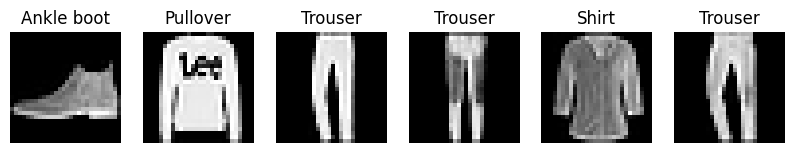

In [ ]:
# STEP 11: Show sample predictions

labels = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,4))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(labels[y_pred_m[i]])
    plt.axis('off')
plt.show()
